In [1]:
import os
os.chdir('../../../..')
print(os.getcwd())
from Simulation.libraries.SimulationLib.Environment import *
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats
from scipy.stats import levene
import numpy as np
import csv
from ExperimentTools.utils.ExperimentLogger import EvaluationLogger, ExperimentLogger, ShortestPath
import pickle
import math

/Users/titonka/FAIRIS


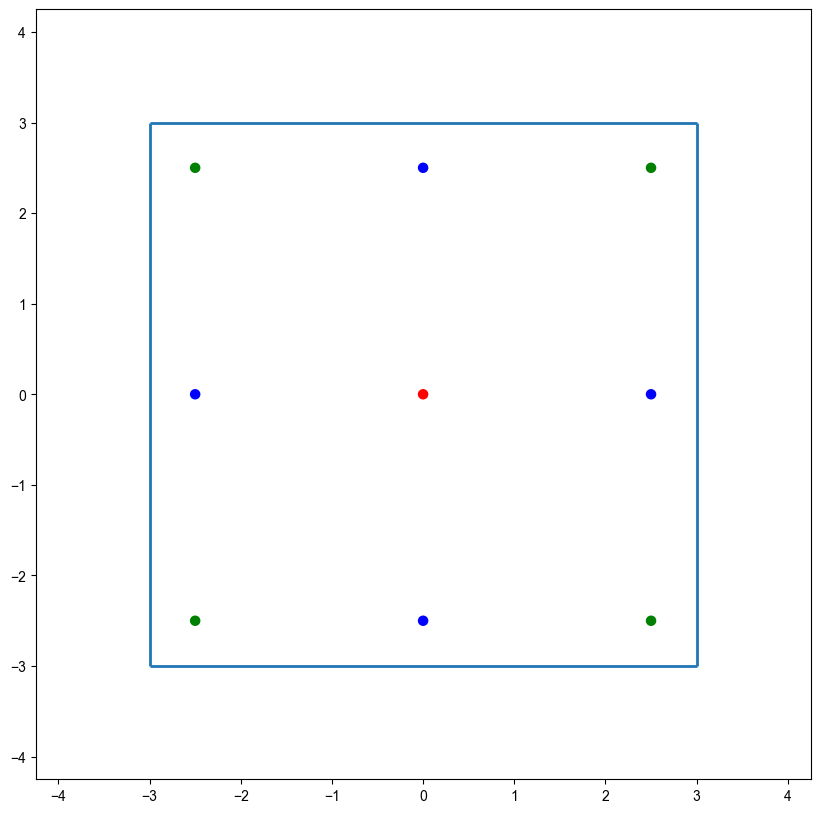

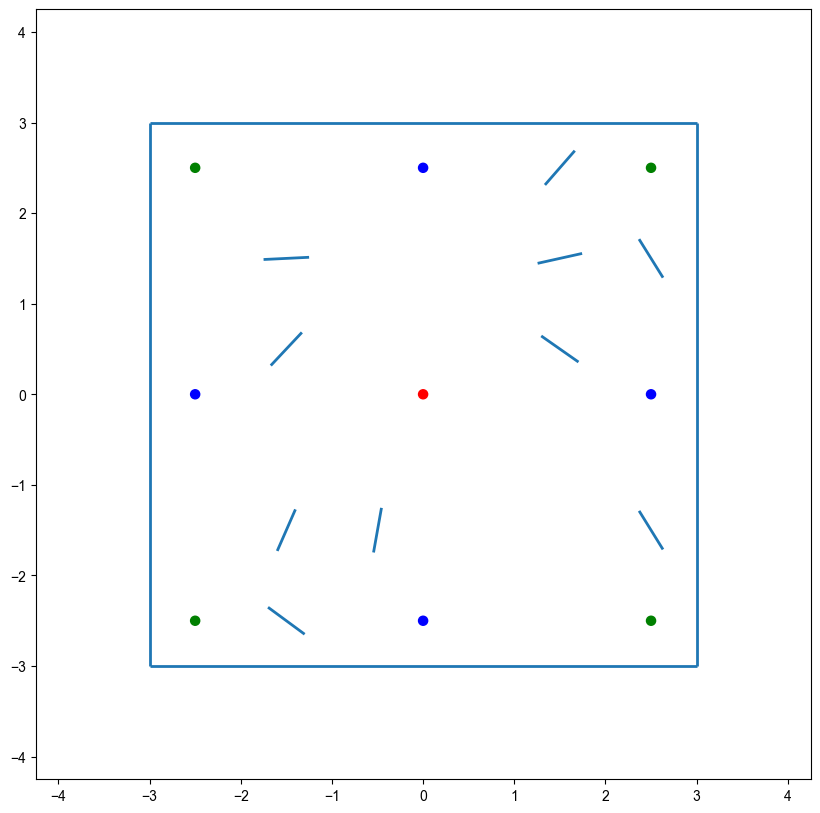

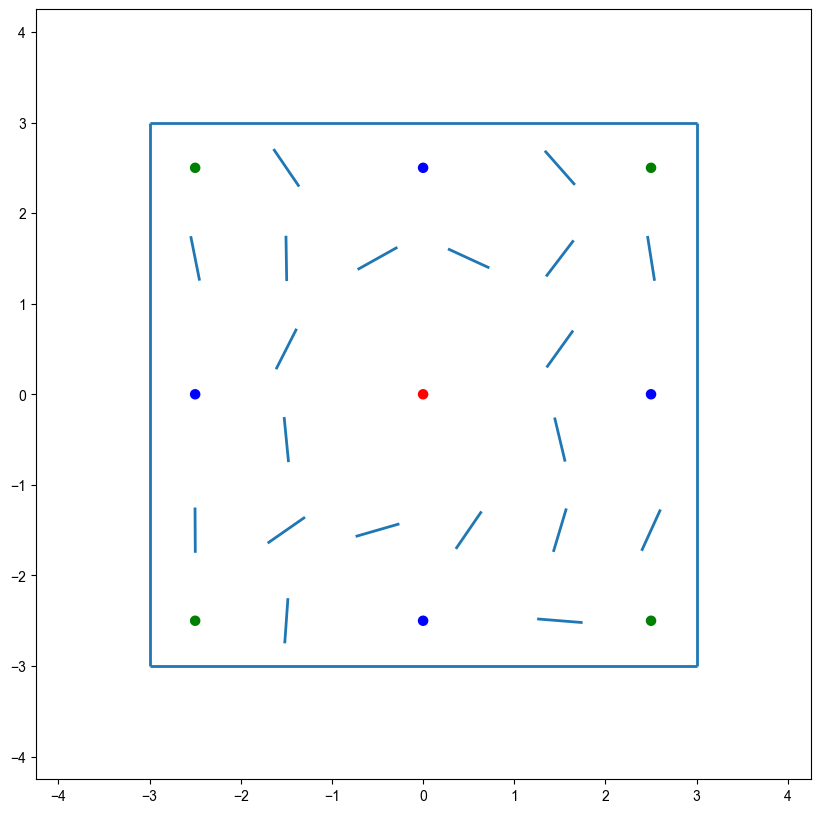

In [2]:
maze_files = ['WM00_paths.pkl','WM10_paths.pkl','WM20_paths.pkl']
mazes = []
for maze_file in maze_files:
    with open('Simulation/worlds/mazes/Experiment1/Paths/'+maze_file,'rb') as file:
        mazes.append(pickle.load(file))
def load_episodes_from_csv(filename):
    episodes = []
    with open(filename, 'r') as file:
        reader = csv.reader(file)
        current_episode = []
        
        for row in reader:
            if not row:  # Blank line signifies a new episode
                if current_episode:
                    episodes.append(current_episode)
                    current_episode = []
                continue
            
            # Convert row to a tuple of floats and add to the current episode
            current_episode.append(list(map(float, row)))
        
        if current_episode:  # Add the last episode if it exists
            episodes.append(current_episode)

    return episodes

def log_optimality_ratio(exp_data):
    maze_names = ['WM00','WM10','WM20']
    path_data = []
    name_index = 0
    for maze in mazes:
        starting_points = []
        path_lengths = []
        for path in maze.paths:
            starting_points.append(path.path[0])
            path_lengths.append(len(path.path)-1)
        path_data.append(ShortestPath(maze_names[name_index],starting_points,path_lengths))
        name_index += 1
    
    path_metrics = {
        'WM00': path_data[0],
        'WM10': path_data[1],
        'WM20': path_data[2]
    }
    for experiment in exp_data:
        maze_ver = experiment.maze_file
        if maze_ver == 'WM00':
            data_index = 0
        elif maze_ver == 'WM10':
            data_index = 1
        shortest_path = path_metrics.get(maze_ver)
        for episode in experiment.episodes:
            start = (episode.path_xs[0] , episode.path_ys[0])
            min_dist = 100
            for s in shortest_path.starting_points:
                dist = math.sqrt((start[0] - s[0])**2 + (start[1]-s[1])**2)
                if dist < min_dist:
                    min_dist = dist
                    eps_start = s  
            min_length = int(shortest_path.path_lengths.get(eps_start))        
            optimality_ratio = (episode.path_length - min_length)/min_length
            experiment.log_optimality_ratio_of_paths(optimality_ratio)
            
maze_names = ['WM00','WM10','WM20']
path_data = []
name_index = 0
for maze in mazes:
    starting_points = []
    path_lengths = []
    for path in maze.paths:
        starting_points.append(path.path[0])
        path_lengths.append(len(path.path)-1)
    path_data.append(ShortestPath(maze_names[name_index],starting_points,path_lengths))
    name_index += 1

path_metrics = {
    'WM00': path_data[0],
    'WM10': path_data[1],
    'WM20': path_data[2]
}

In [3]:
evaluation_data_PC = []
evaluation_data_No_PC = []
with open('logs/LargeScale/UnseenStartEval/AllPPOEvalData_PC_unseen','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        evaluation_data_PC.append(EvaluationLogger(old_data=experiment))

with open('logs/LargeScale/UnseenStartEval/AllPPOEvalData_No_PC_unseen','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        evaluation_data_No_PC.append(EvaluationLogger(old_data=experiment))

log_optimality_ratio(evaluation_data_PC)
log_optimality_ratio(evaluation_data_No_PC)

In [10]:
def aggregate_optimality_ratios(evaluation_loggers):
    optimality_ratios = []
    for logger in evaluation_loggers:
        optimality_ratios.extend(logger.optimality_ratio_history)
    return optimality_ratios

def prepare_data_for_plotting(eval_data, model_type):
    data = []
    
    for logger in eval_data:
        maze_name = 'WM00' if 'WM00' in logger.maze_file else 'WM10'
        for ratio in logger.optimality_ratio_history:
            data.append({
                'Model Type': model_type,
                'Optimality Ratio': ratio,
                'Maze': maze_name
            })
    
    return pd.DataFrame(data)

def plot_boxplots(eval_data_pc, eval_data_no_pc):
    # Prepare the data
    data_pc = prepare_data_for_plotting(eval_data_pc, 'With Place Cells')
    data_no_pc = prepare_data_for_plotting(eval_data_no_pc, 'Without Place Cells')
    
    # Combine data for both model types
    combined_data = pd.concat([data_pc, data_no_pc])
    
    # Create box plots
    plt.figure(figsize=(14, 7))
    sns.boxplot(x='Maze', y='Optimality Ratio', hue='Model Type', data=combined_data, showfliers=False)
    
    plt.title('Performance Comparison of Models with and without Place Cells')
    plt.xlabel('Maze')
    plt.ylabel('Optimality Ratio')
    plt.legend(title='Model Type')
    plt.show()

NameError: name 'final_ratios_WM00_PC' is not defined

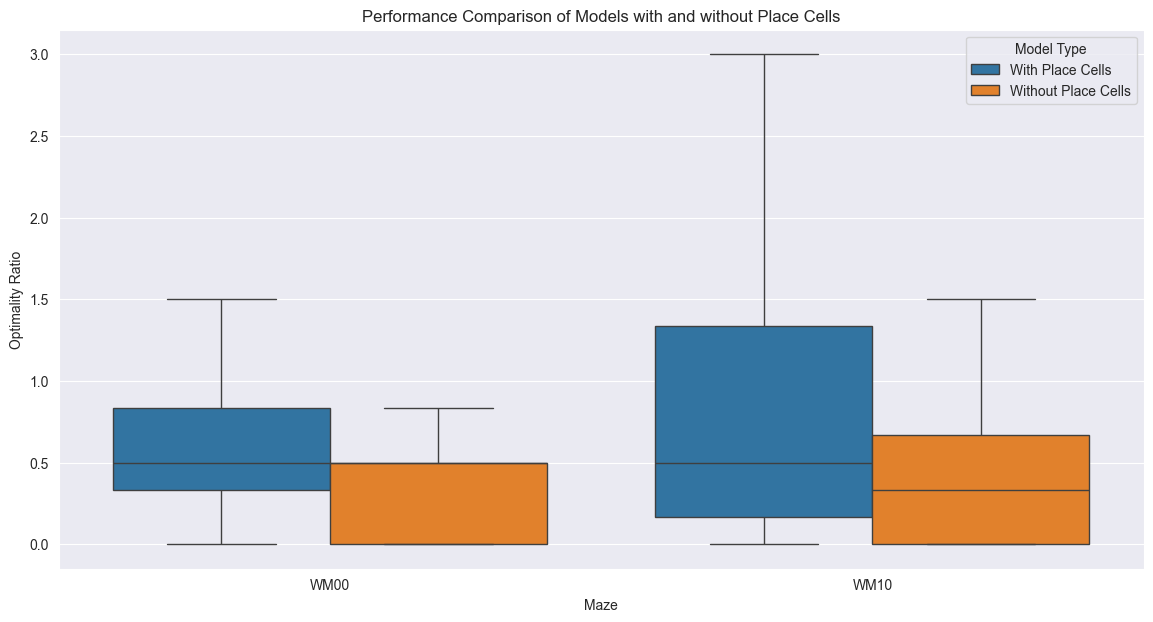

In [9]:
plot_boxplots(evaluation_data_PC, evaluation_data_No_PC)